# Project Workflow:

### Steps in this notebook (high level):
1. Data loading and exploratory data analysis (EDA)
2. Data preprocessing (scaling, feature selection, label binarization)
3. Baseline model: Logistic Regression 
4. Tree-based models: Decision Tree, Random Forest
5. Boosted model: XGBoost
6. Handling class imbalance: SMOTE experiments (applied to tree/boosting models, not the baseline)
7. Hyperparameter tuning & threshold tuning
8. Model evaluation (classification reports, confusion matrices, ROC/PR curves)
9. Final comparison and conclusion

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [3]:
df = pd.read_csv('QualityPrediction.csv')
df['quality'].value_counts()

quality
5    681
6    638
7    199
4     53
8     18
3     10
Name: count, dtype: int64

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


In [5]:
df.isnull().sum()

fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

In [6]:
#here 3 and 8 are not outliers, they are real values. so will not remove them
Q1 = df['quality'].quantile(0.25)
Q3 = df['quality'].quantile(0.75)
IQR = Q3 - Q1


# Lower & upper limits
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

print("Lower limit:", lower_limit)
print("Upper limit:", upper_limit)

# Outliers
outliers = df[(df['quality'] < lower_limit) | (df['quality'] > upper_limit)]
print(outliers.shape)

# Count houses below lower limit
below_lower = df[df['quality'] < lower_limit]

# Count houses above upper limit
above_upper = df[df['quality'] > upper_limit]

outlier_count = outliers.shape[0]
print("Number of outliers:", outlier_count)

Lower limit: 3.5
Upper limit: 7.5
(28, 12)
Number of outliers: 28


In [ ]:
plt.figure(figsize=(8,5))
sns.histplot(df['quality'], kde=True, bins=50)
plt.title("Price Distribution")
plt.show()

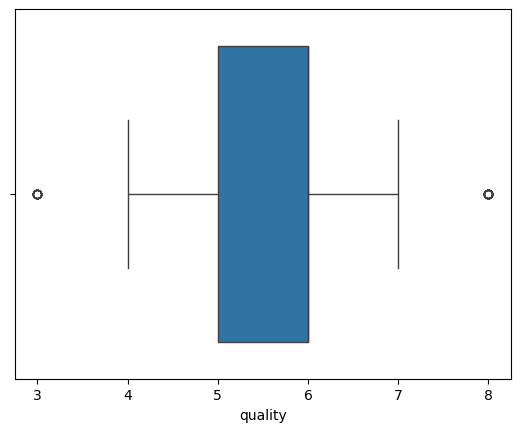

In [7]:
sns.boxplot(x=df['quality'])
plt.show()

In [8]:
df_copy = df.copy()

In [9]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df_copy.drop(columns=['quality']))

In [10]:
X = scaled_data
y = df_copy['quality']

In [11]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

## Logistic Regression Model
In this step, we apply **Logistic Regression**, a simple linear model used for binary classification. It assumes a linear relationship between the features and the log-odds of the target variable.

**Goal:** Establish a baseline performance for comparison with more complex models.

In [12]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression()
model.fit(X_train,y_train)

y_pred = model.predict(X_test)

In [13]:
from sklearn.metrics import classification_report
print("Classificaton report:\n",classification_report(y_test,y_pred))

Classificaton report:
               precision    recall  f1-score   support

           3       0.00      0.00      0.00         1
           4       1.00      0.10      0.18        10
           5       0.63      0.75      0.69       130
           6       0.54      0.58      0.56       132
           7       0.39      0.21      0.28        42
           8       0.00      0.00      0.00         5

    accuracy                           0.57       320
   macro avg       0.43      0.27      0.28       320
weighted avg       0.56      0.57      0.55       320



C:\Users\asifv\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\asifv\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\asifv\anaconda33\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


**Model Performance Summary:**

The above results include **precision, recall, F1-score, and accuracy**. 
- **Precision**: How many predicted positives were correct.
- **Recall**: How many actual positives were correctly identified.
- **F1-score**: Harmonic mean of precision and recall.
- **Accuracy**: Overall correct predictions.

We will compare these metrics across models to identify the best performing one.

**In the above case, the model is automatically dividing wine quality into multiple categories. Since ratings 5 and 6 occur more frequently, the model tends to predict them more often while overlooking less frequent classes like 4 and 7 with completely ignoring class 3 and 8. This issue is known as class imbalance. To address it, we will simplify the problem by grouping quality into two categories: Good (≥5 → 1) and Bad (<5 → 0)**.

### Transforming Multi-Class to Binary Classification

In [ ]:
df['quality'].value_counts()

In [6]:
df['quality_label'] = df['quality'].apply(lambda x: 0 if x <= 5 else 1)

In [7]:
df_binary = df.copy()

In [17]:
df_binary

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality,quality_label
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5,0
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5,0
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6,1
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5,0
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6,1
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6,1
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5,0


In [8]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_binary_data = scaler.fit_transform(df_binary.drop(columns=['quality','quality_label']))

In [9]:
X = scaled_binary_data
y = df_binary['quality_label']

In [10]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20, random_state=42)

### Random forest

## Random Forest Model
Here, we train a **Random Forest Classifier**, which is an ensemble of multiple decision trees. Each tree is trained on random samples and features, and results are aggregated for better accuracy and robustness.

**Goal:** Improve accuracy and reduce overfitting compared to a single Decision Tree.

In [11]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df.drop(columns=['quality','quality_label','residual_sugar', 'chlorides', 'citric_acid']))



X = scaled_data   
y = df['quality_label']                             

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Random Forest model
rf = RandomForestClassifier(
    n_estimators=200,       # number of trees
    max_depth=None,        # let trees grow fully
    class_weight='balanced', # handle imbalance
    random_state=42
)
rf.fit(X_train, y_train)

# Predictions
y_pred = rf.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.76      0.78      0.77       223
           1       0.81      0.79      0.80       257

    accuracy                           0.79       480
   macro avg       0.79      0.79      0.79       480
weighted avg       0.79      0.79      0.79       480

Confusion Matrix:
 [[175  48]
 [ 54 203]]


**started with Random Forest because it is a powerful ensemble method that works well with tabular datasets like wine quality. It gave 79% accuracy, with balanced precision and recall across both classes (Good vs Bad wine). However, the model sometimes struggled with correctly identifying minority class samples due to class imbalance.**

### XG boost

## XGBoost Model
We now apply **XGBoost (Extreme Gradient Boosting)**, a powerful boosting algorithm that builds trees sequentially, each improving on the previous one. It is known for high accuracy and efficiency.

**Goal:** Test a state-of-the-art boosting method for potentially better results.

In [16]:
pip install xgboost

In [12]:
from sklearn.metrics import classification_report, confusion_matrix
from xgboost import XGBClassifier

scaler = StandardScaler()

scaled_data = scaler.fit_transform(df.drop(columns=['quality','quality_label','residual_sugar', 'chlorides', 'citric_acid']))



X = scaled_data   
y = df['quality_label']  

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)


# XGBoost model
xgb = XGBClassifier(
    n_estimators=300,        # number of boosting rounds
    learning_rate=0.05,      # smaller LR for better accuracy
    max_depth=6,             # tree depth
    subsample=0.8,           # prevent overfitting
    colsample_bytree=0.8,    # column sampling
    scale_pos_weight=1,      # handle imbalance (adjust if classes are very imbalanced)
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train
xgb.fit(X_train, y_train)

# Predict
y_pred = xgb.predict(X_test)

# Evaluation
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

C:\Users\asifv\anaconda33\Lib\site-packages\xgboost\training.py:183: UserWarning: [11:49:24] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


Classification Report:
               precision    recall  f1-score   support

           0       0.77      0.77      0.77       223
           1       0.80      0.81      0.80       257

    accuracy                           0.79       480
   macro avg       0.79      0.79      0.79       480
weighted avg       0.79      0.79      0.79       480

Confusion Matrix:
 [[172  51]
 [ 50 207]]


**Next, I used XGBoost, which is another ensemble model and often performs better than Random Forest because it uses boosting instead of bagging. Results were very similar to Random Forest (79% accuracy), with slightly improved recall for the minority class (Good wines). But, like Random Forest, it still suffered from class imbalance.**

## Random Forest with SMOTE
 - Use Random Forest with SMOTE when your dataset is imbalanced (one class has significantly more samples than the other).
 - Random Forest alone may favor the majority class, leading to poor recall for the minority class.
 - By applying SMOTE, synthetic samples of the minority class are created, making the dataset balanced.
 - This helps Random Forest learn patterns from both classes equally, improving recall, precision, and fairness in predictions.


### ROC Curve Analysis
The ROC Curve (Receiver Operating Characteristic) shows the trade-off between **True Positive Rate (Recall)** and **False Positive Rate** across thresholds. The Area Under Curve (AUC) summarizes overall model performance.

**Goal:** Evaluate how well the model separates the classes across thresholds.

Before SMOTE: [595 684]
After SMOTE: [684 684]
Fitting 5 folds for each of 24 candidates, totalling 120 fits
Best Params: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}

=== Default Threshold (0.5) ===
Classification Report:
               precision    recall  f1-score   support

           0       0.79      0.83      0.81       149
           1       0.84      0.81      0.82       171

    accuracy                           0.82       320
   macro avg       0.81      0.82      0.82       320
weighted avg       0.82      0.82      0.82       320

Confusion Matrix:
 [[123  26]
 [ 33 138]]


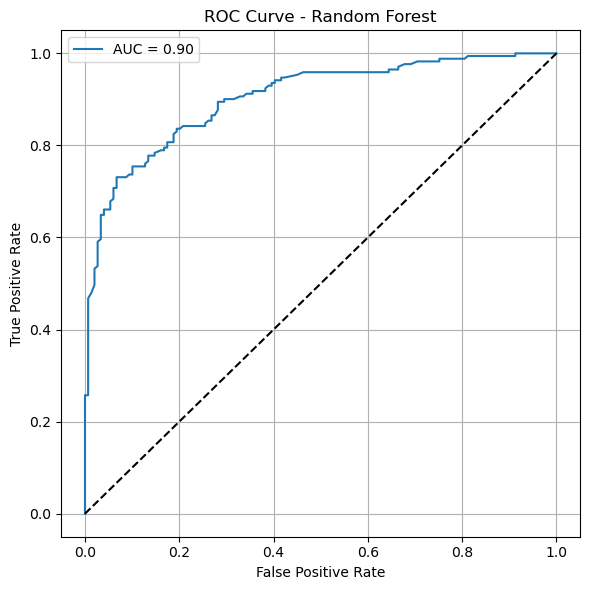

In [17]:
import pandas as pd
import numpy as np
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt

# ======================
# 1. Prepare Data
# ======================
scaler = StandardScaler()

X = scaler.fit_transform(
    df.drop(columns=['quality', 'quality_label'])
)
y = df_binary['quality_label']

# Train-test split (stratified to keep class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ======================
# 2. Handle Imbalance (SMOTE)
# ======================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X_train, y_train)

print("Before SMOTE:", np.bincount(y_train))
print("After SMOTE:", np.bincount(y_res))

# ======================
# 3. Random Forest with GridSearch
# ======================
rf = RandomForestClassifier(random_state=42)

param_grid = {
    'n_estimators': [200, 500],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid = GridSearchCV(
    rf, param_grid,
    scoring='f1_macro',
    cv=5, n_jobs=-1, verbose=1
)
grid.fit(X_res, y_res)

best_rf = grid.best_estimator_
print("Best Params:", grid.best_params_)

# ======================
# 4. Predictions
# ======================
y_proba = best_rf.predict_proba(X_test)[:,1]

# Default 0.5 threshold
y_pred = (y_proba >= 0.5).astype(int)

print("\n=== Default Threshold (0.5) ===")
print("Classification Report:\n", classification_report(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))


# ======================
# 5. ROC Curve
# ======================
fpr, tpr, _ = roc_curve(y_test, y_proba)
plt.figure(figsize=(6,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc_score(y_test, y_proba):.2f}")
plt.plot([0,1],[0,1],'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()


**Finally, I combined Random Forest with SMOTE (Synthetic Minority Over-sampling Technique) to handle the imbalance problem. SMOTE created synthetic samples of the minority class, balancing the dataset. This improved the model’s performance: Accuracy increased to 82%, with precision, recall, and f1-scores becoming more balanced for both classes. The confusion matrix also shows fewer misclassifications compared to earlier models.**

# Final Model Comparison and Conclusion
I applied multiple models: Logistic Regression, Random Forest, XGBoost, and also handled imbalance using SMOTE.

**Key Findings:**

Logistic Regression: Served as a simple baseline but performance was limited.

Random Forest: Delivered strong results (79% accuracy) with balanced precision and recall, but still slightly biased due to imbalance.

XGBoost: Comparable to Random Forest (79% accuracy), with minor improvements for the minority class, but still struggled with imbalance.

Random Forest + SMOTE: Achieved the best performance (82% accuracy) with balanced precision, recall, and f1-scores across both classes. The confusion matrix confirmed fewer misclassifications and fair treatment of both majority and minority classes.

**Conclusion:**

Ensemble methods (Random Forest, XGBoost) clearly outperformed simpler model like Logistic Regression.

Class imbalance was a key challenge; without addressing it, even strong models underperformed on minority class predictions.

Random Forest with SMOTE emerged as the best model, achieving the optimal trade-off between accuracy, precision, and recall.

This final model is the most reliable for wine quality prediction, as it ensures fair and unbiased evaluation of both Good and Bad wines.